# Gradient Descent

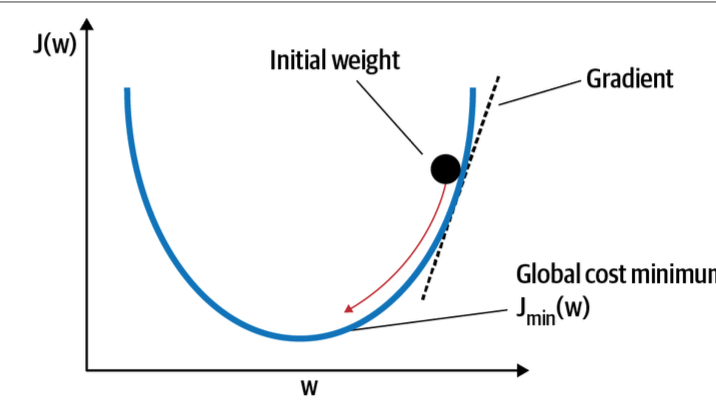

Descenso de Gradiente es un algoritmo de optimización para minimizar la función de costos de diferentes algoritmos de Machine Learning. Vamos a ver 10 tipos de descenso de gradiente más populares en un Marco estilo Keras/Tensorflow para Redes Neuronales Profundas. 

Se utiliza en modelos de deep learning para actualizar los pesos de redes neuronales a través de backpropagation.

# Componentes de Descenso de Gradiente

Hay 3 formas principales de cómo estos optimizadores funcionan sobre el descenso de Gradiente:
1. Modificando la tasa de aprendizaje. Multiplican por factor positivo para que se conviertan en más pequeñas conforme avanza la iteración (el tamaño lo determina el gradiente)
2. Modificando el gradiente. Utilizan un suavizamiento exponencial de gradiente (momentum) en lugar de tomar sólo un valor con el caso plain vanilla. 
3. Modificando ambos. 

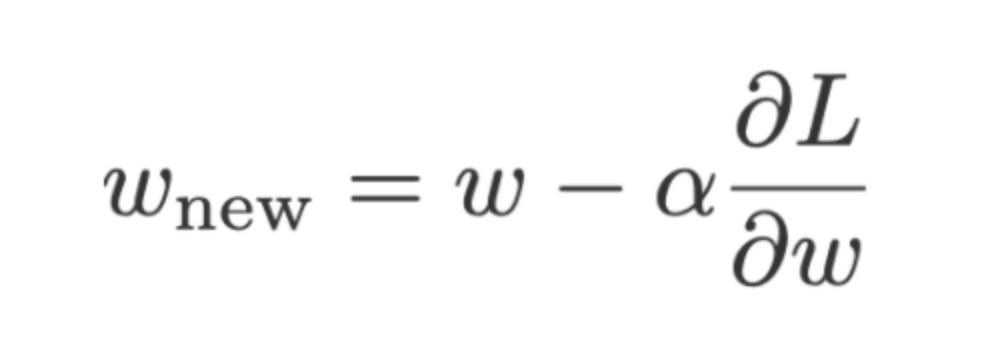

# Notación 

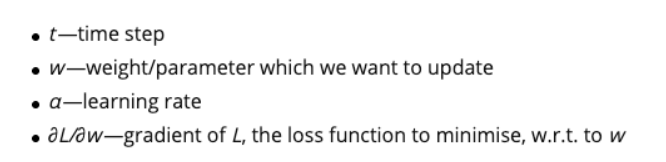

# Los optimizadores, su desarrollo y componente en el que actúan.

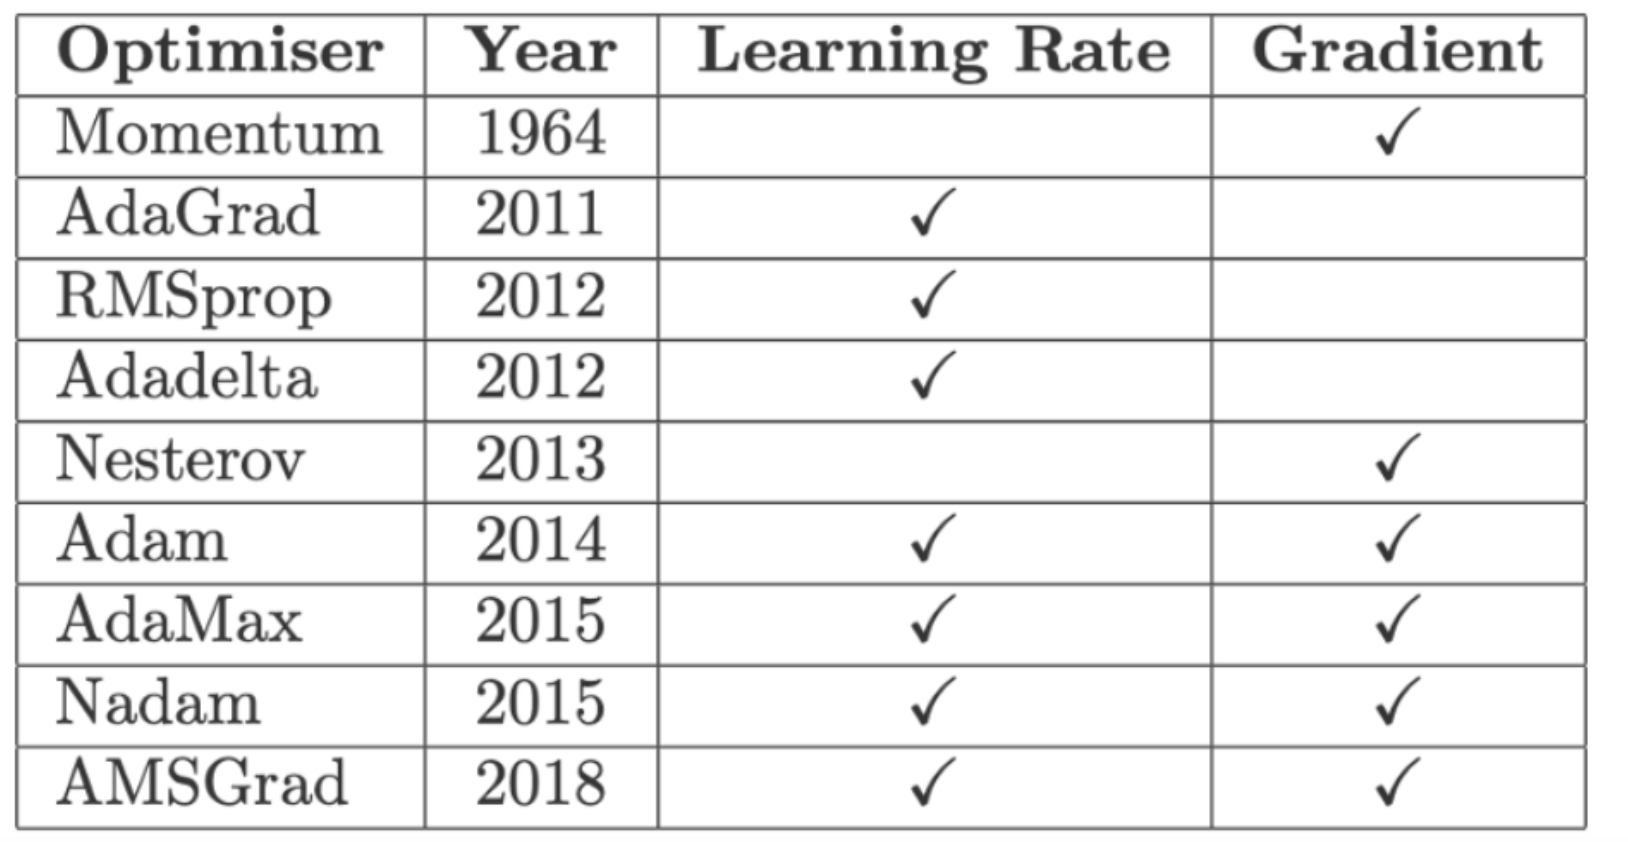

# Flujo de cómo han ido avanzando. 

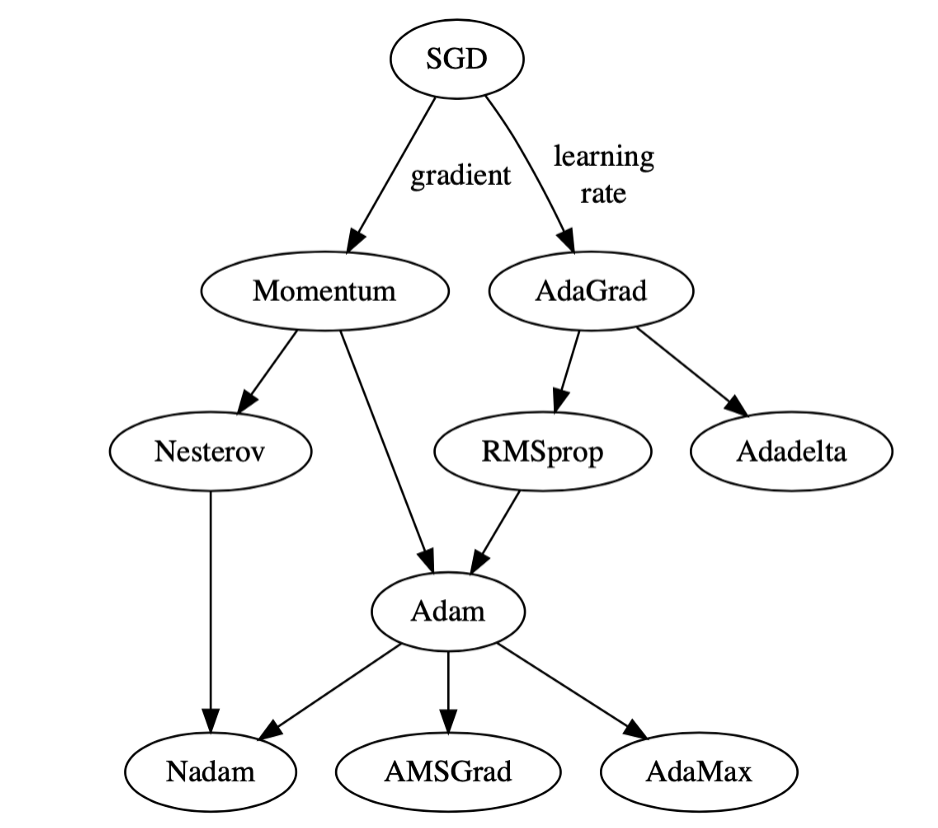

# Contenido

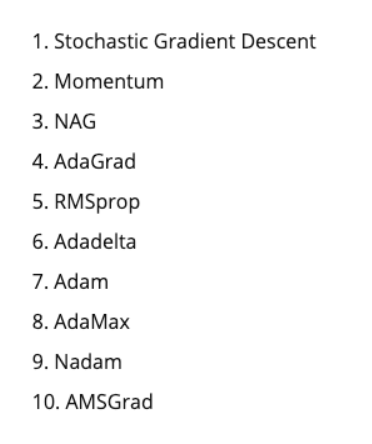

# 1. Descenso de Gradiente Estocástico Plain Vanilla

El descenso de gradiente más sencillo actualiza los pesos actuales w_t usando el gradiente_actual_t mutiplicado por un factor que se llama tasa de aprendizaja: alfa. 

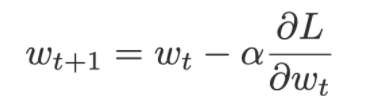

# 2. Momentum

En lugar de dedepender sólo del gradiente actual para actualizar los pesos, descenso de gradiente con momentum (Polyak,1964)


https://www.researchgate.net/publication/243648538_Some_methods_of_speeding_up_the_convergence_of_iteration_methods

reemplaza el gradiente actual con V_t (velocidad), el cual es promedio ponderado exponencialmente (suavizado exponencial) del actual y de los gradientes pasados (hasta el tiempo t). Esa actualización de momentum se convertirá en la actualización para el componente de gradiente. 

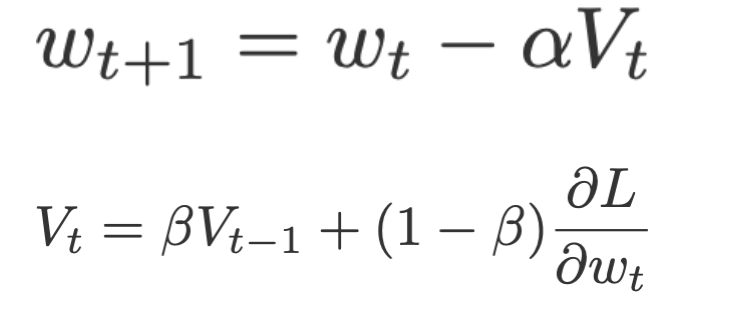

V se inicializa en 0 y valor de B es usualmente 0.9

Muchos artículos de referencia le asocian momentum a Ning Qian, 1999 
(https://www.semanticscholar.org/paper/On-the-momentum-term-in-gradient-descent-learning-Qian/735d4220d5579cc6afe956d9f6ea501a96ae99e2)

Sin embargo, el paper Sutskever, 2013 se lo atribuye a Polyak 1964. 

(http://proceedings.mlr.press/v28/sutskever13.pdf)

# 3. Nesterov Accelerate Gradient (NAG)

Después de que el paper de Polyak tomara relevancia, actualizaciones similares surgieron, (http://proceedings.mlr.press/v28/sutskever13.pdf)

Se cambia el componente de V_t, ahora siendo gradientes proyectados. 

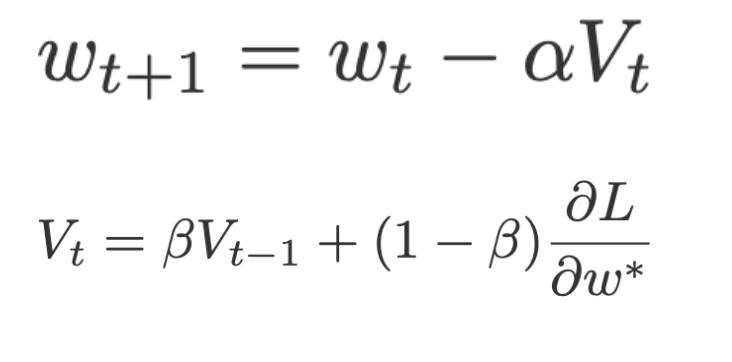

El último termino es un gradiente proyectado. Este valor puede ser obtenido yendo un pase adelante utilizando el gradiente anterior. Esto significa que para el tiempo t, tenemos que hacer otro forward propagation antes de ejecutar el backpropagation. Los pasos son: 

1. Actualizar los pesos actuales w_t a un espacio proyectado w* usando la velocidad previa. 

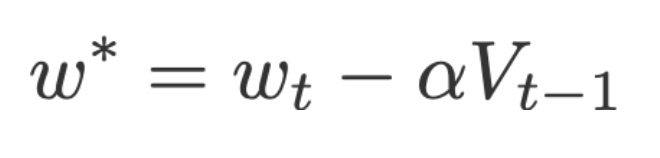

2. Hacer un Forward Propagation, pero usando los pesos proyectados
3. Obtener un nuevo gradiente
4. Calcular V_t y w_t+1 respectivamente

B común es 0.9

El paper original de Nesterov, 1983 no era sobre descenso de gradiente, era sobre teoremas de convergencia. 

# 4. AdaGrad

Gradiente Adaptativo o AdaGrad (Duchi, 2011) 
https://www.jmlr.org/papers/volume12/duchi11a/duchi11a.pdf
trabaja en la tasa de aprendizaje al dividir la tasa por la raiz de S, que es suma acumulada de gradientes (actuales y pasados) cuadrados. El componente de Gradiente se mantiene sin cambios

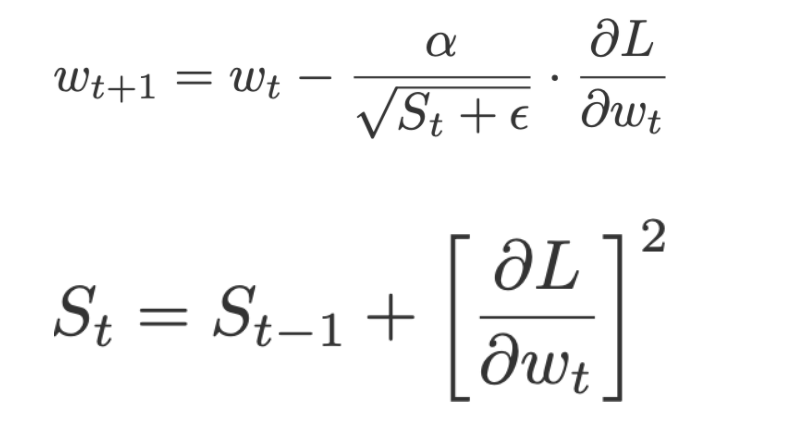

S se inicializa en 0. Se le agrega una "e" en el denominador, Keras le llama factor fuzz, un valor pequeño floating para asegurarnos que nunca se divida entre 0. 

Valores Default de Keras: 
a=.01
e=10e-7
https://keras.io/api/optimizers/#adagrad

# 5. RMSprop

Root Mean Square prop o RMSprop (Hinton, 2012). http://www.cs.toronto.edu/~tijmen/csc321/slides/lecture_slides_lec6.pdf

Es otro método con tasas de aprendizaje adaptativas que es una mejora de AdaGrad. En lugar de tomar la suma de cuadrados de los gradientes, mejor se toma el suavizamiento exponencial de los gradientes. 


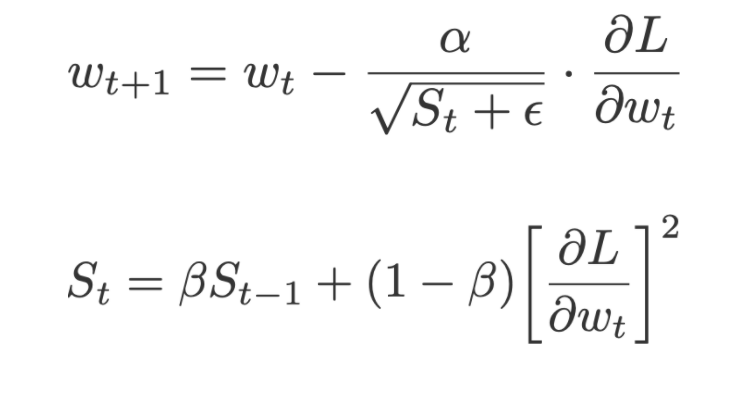

valores default de keras: 
a=.001, b=.9 (recomiendan los autores del paper), e=10e-6
https://keras.io/api/optimizers/rmsprop/

# 6. Adadelta

Al igual que RMSprop, Adadelta (Zeiler,2012) https://arxiv.org/abs/1212.5701

es una mejora de AdaGrad, trabajando con la tasa de aprendizaje. 
Adaptative Delta, donde delta se refiere a la diferencia entre los pesos actuales y los nuevos pesos. 

La diferencia con RMSprop está en el valor específico de alfa, utilizando D, suavizamiento exponencial. 



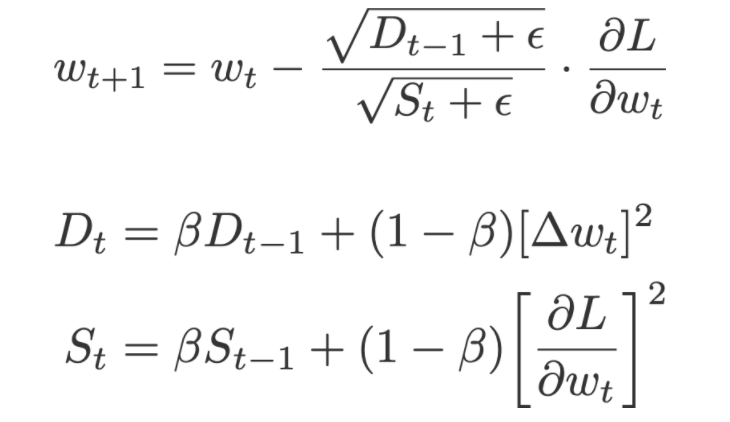


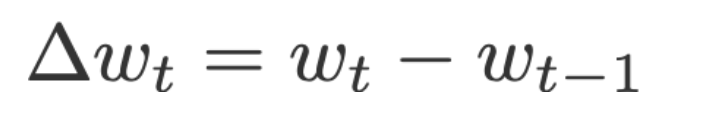

# 7. Adam. 

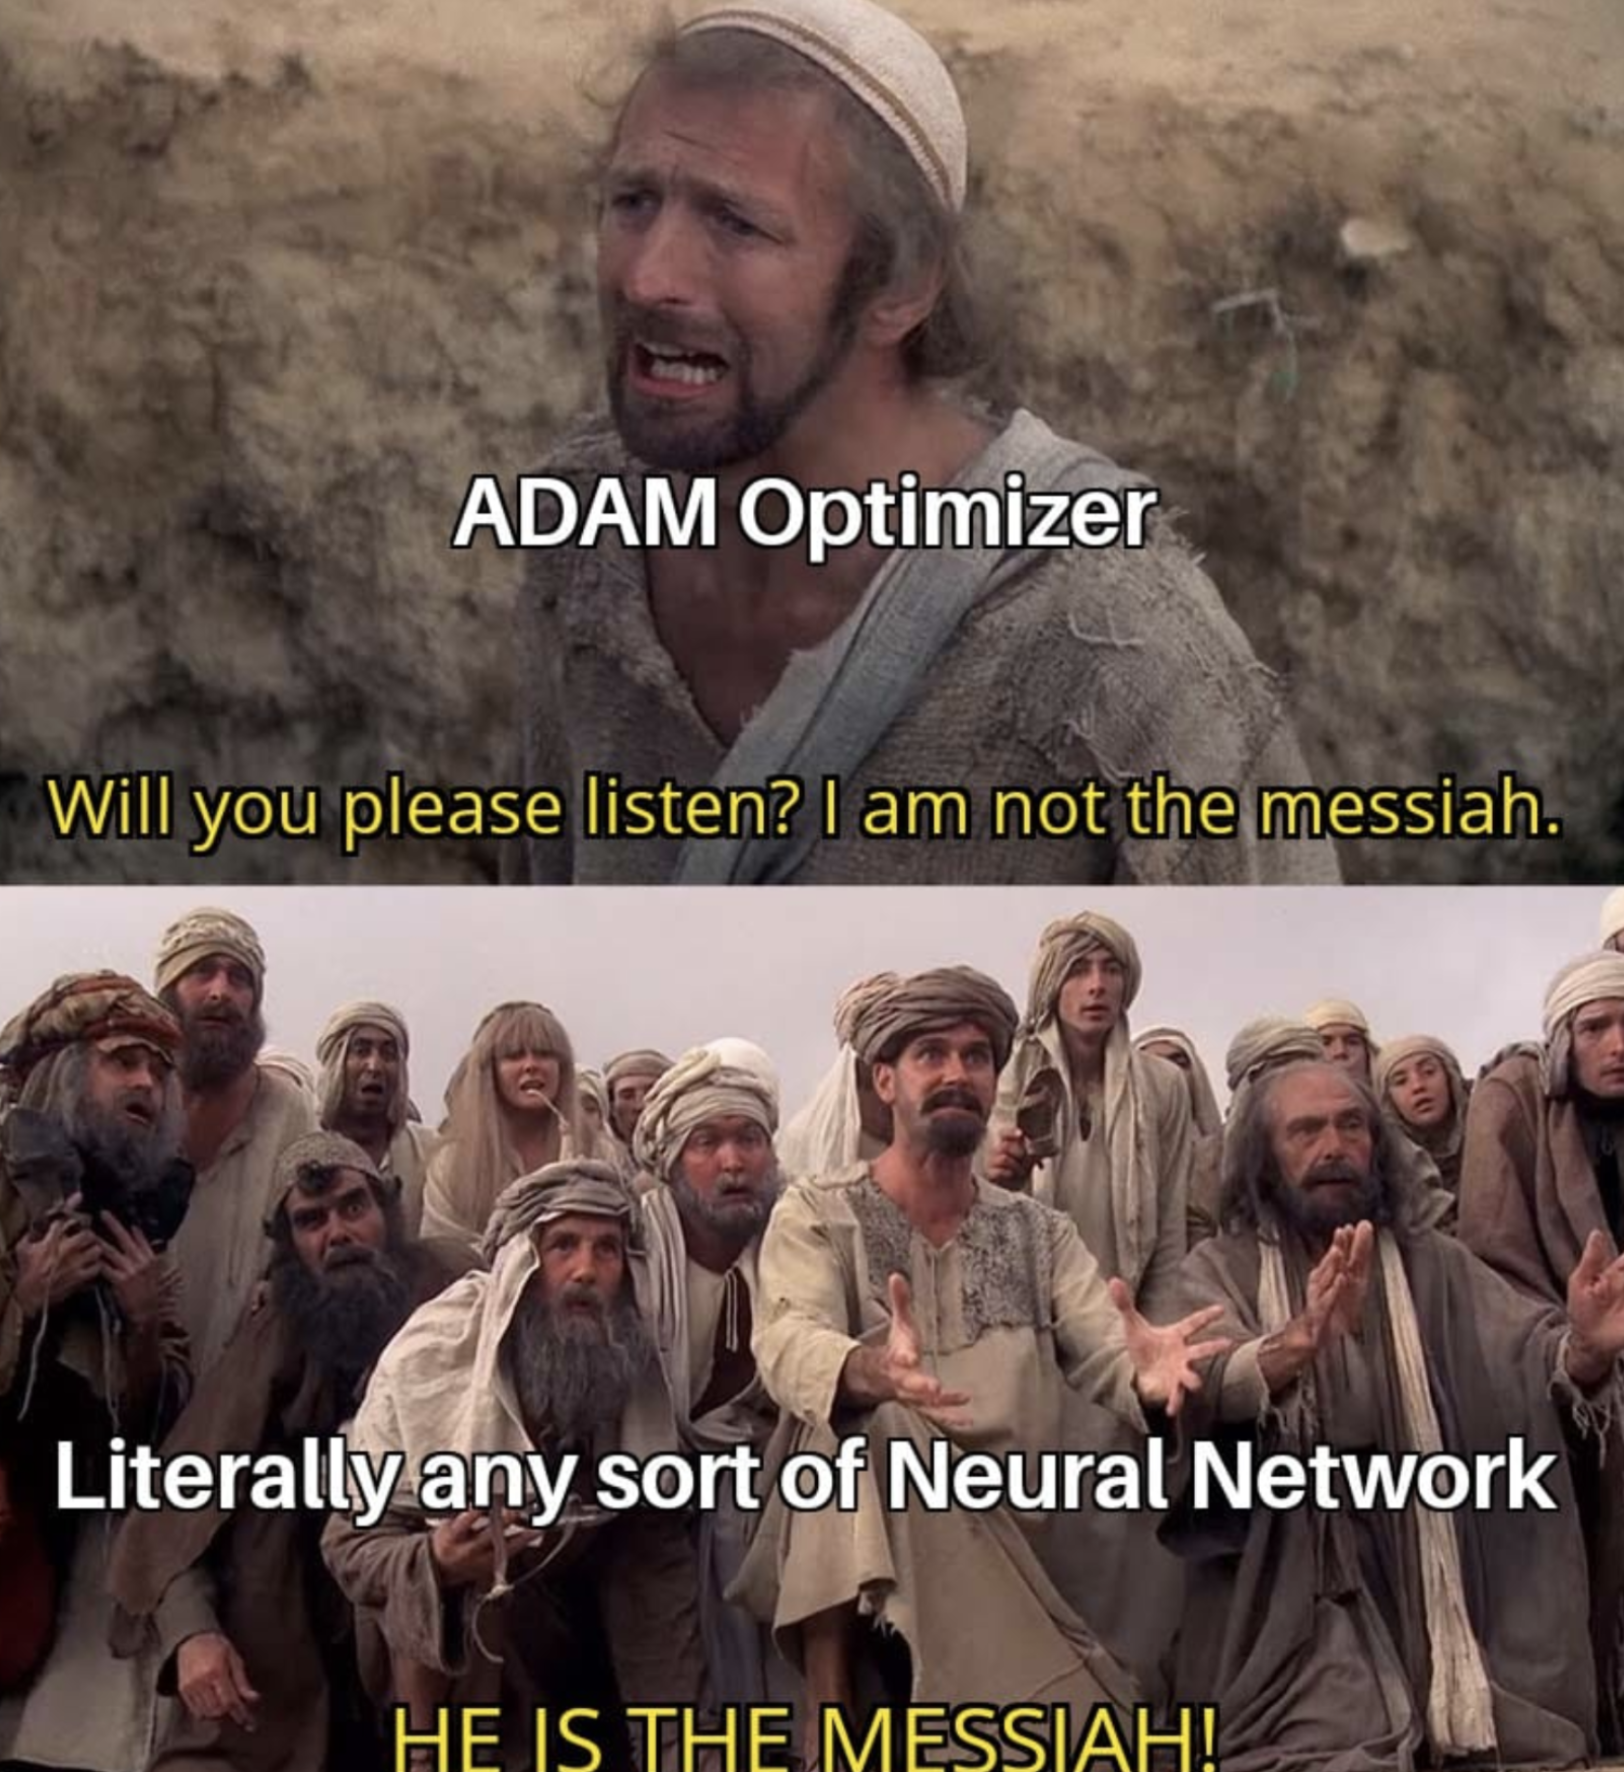

Adaptative Momentum, Adam. (Kingman, 2014) 
 https://arxiv.org/abs/1412.6980
 es uan combinación de momentum y RMSprop. Trabaja con el: 
 
1. Componente Gradiente usando V, suavizamiento exponencial como mentum

2. Tasa de Aprendizaje al dividir alfa por la Raiz de S, suavizamiento exponencial de gradientes cuadrados (RMSProp)


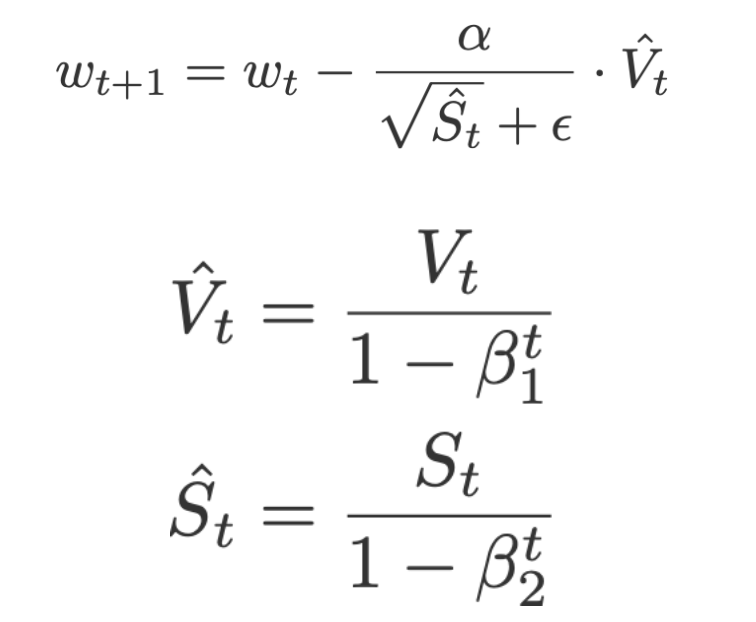

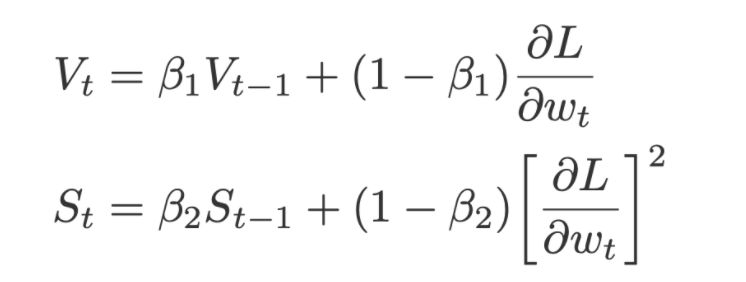

valore default por autores: a=.001, b1=.9 y b2=.999, e=10-8

# 8 AdaMax

AdaMax (Kingman, 2015) 
https://arxiv.org/abs/1412.6980

es una adapatación del optimizador Adam, utilizando normas. V es suavizamiento exponencial de gradientes, S es el suavizamiento exponencial de normas de gradientes, aproximan con la función de máximo. 

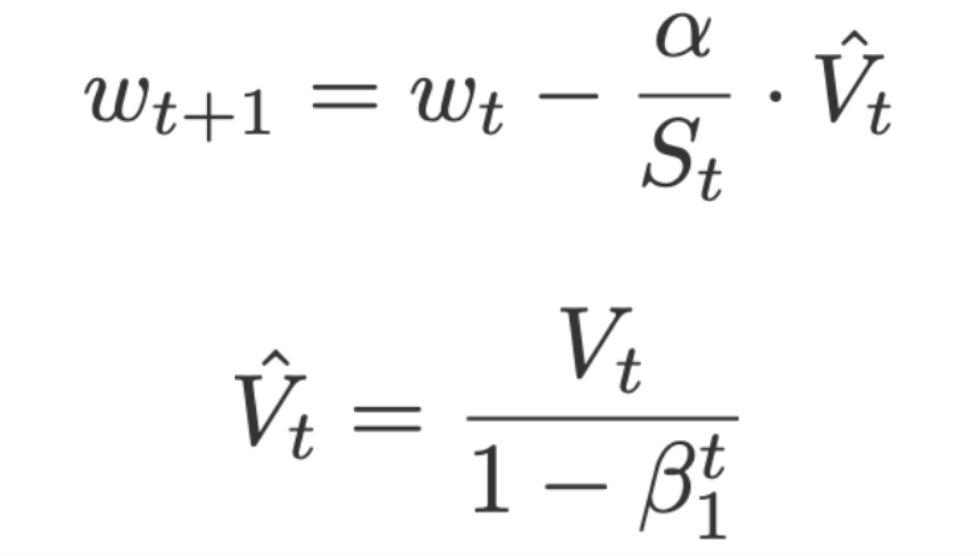

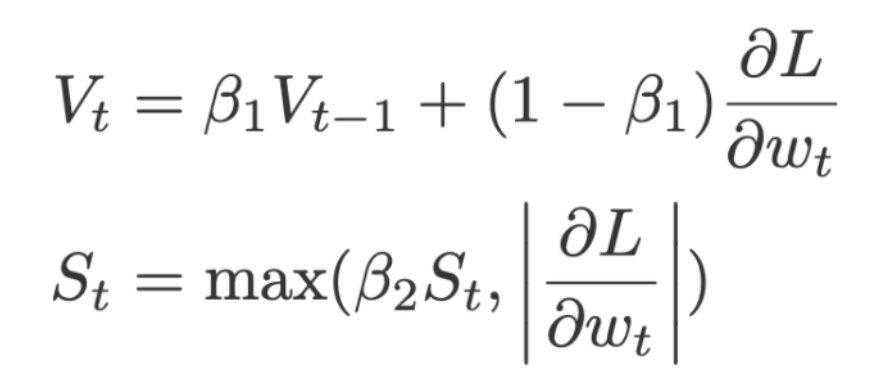

a=.002, b1=.9 y b2=.999

# 9 Nadam

Nadam (Dozat, 2015) http://cs229.stanford.edu/proj2015/054_report.pdf

Es un acrónimo de Nesterov y Adam. Es componente de Nesterov, es una modificación más eficiente del original. 

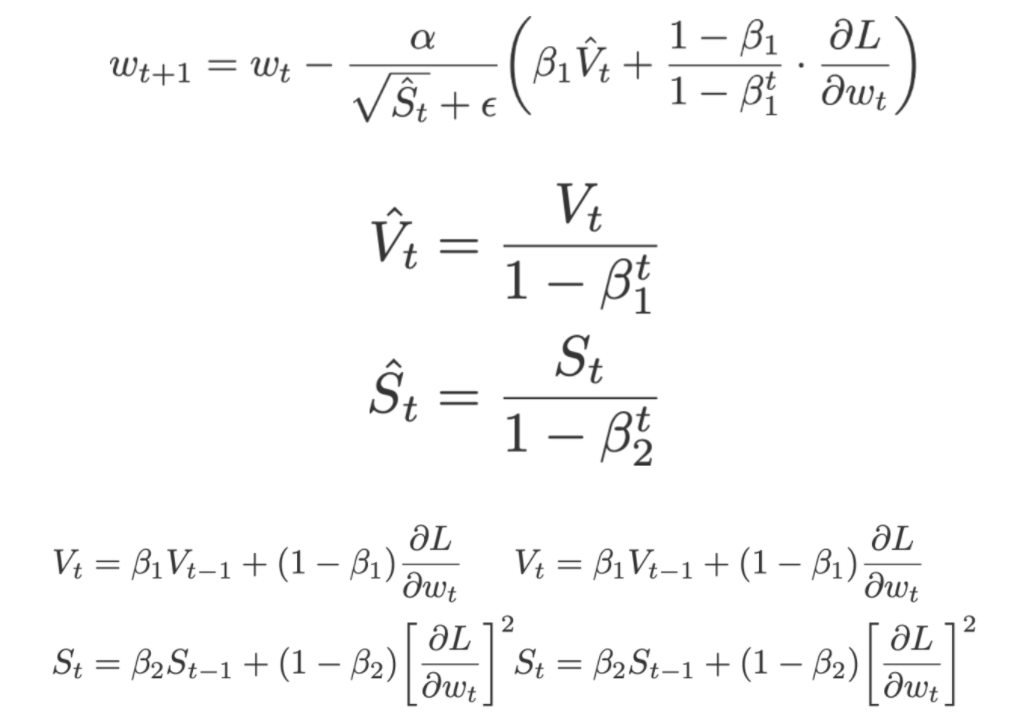

# 10 AMSGrad

Otra variante de Adam (Reddi,2018) 
https://openreview.net/pdf?id=ryQu7f-RZ
esta variante revisa  la tasa de aprendizaje de Adam y asegura que la actual S siempre sea mayor que la anterior 
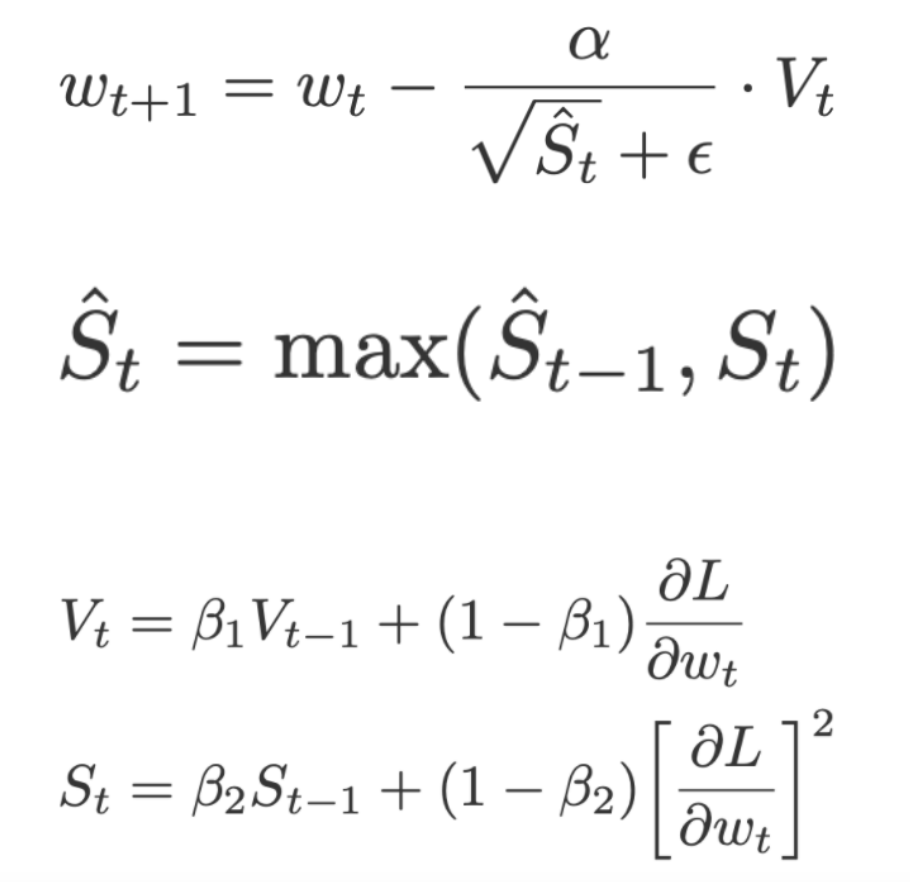
a=.001, b1=.9 b2=.999 e=10e-7 

https://keras.io/api/optimizers/adam/

# Resumen
Realmente **se hacen dos cosas** en los 10 métodos. 

1. **Suaviza el Gradiente e incorporar Historia.**
El Gradiente Vanilla toma únicamente el actual que no es suficiente. 
Queremes ser mejor "guiados", es decir, incluir previos. Que pese más el actual (exponencial), ya que tiene más info pero también incorporemos el pasado para mejorar la guía. 


2. **Dividir Tasa de Aprendizaje por Raíz de Gradientes.**
Adaptar la tasa, adaptarla al gradiente. Asegurarnos que no sea ni grande ni pequeña. La dividmos por el gradiente actual suavizado. Debe ser siempre positiva para tener el mismo signo que el gradinte por eso tomamos valores absolutos o cuadrados. Cuadrados para cancelar y luego sacamos la raíz. Para ser mejor guiados no tomamos el gradiente actual sino la historia(suavizamiento) de gradientes. 


# Práctico. Replicar los diez métodos usando Keras. 

https://keras.io/api/optimizers/


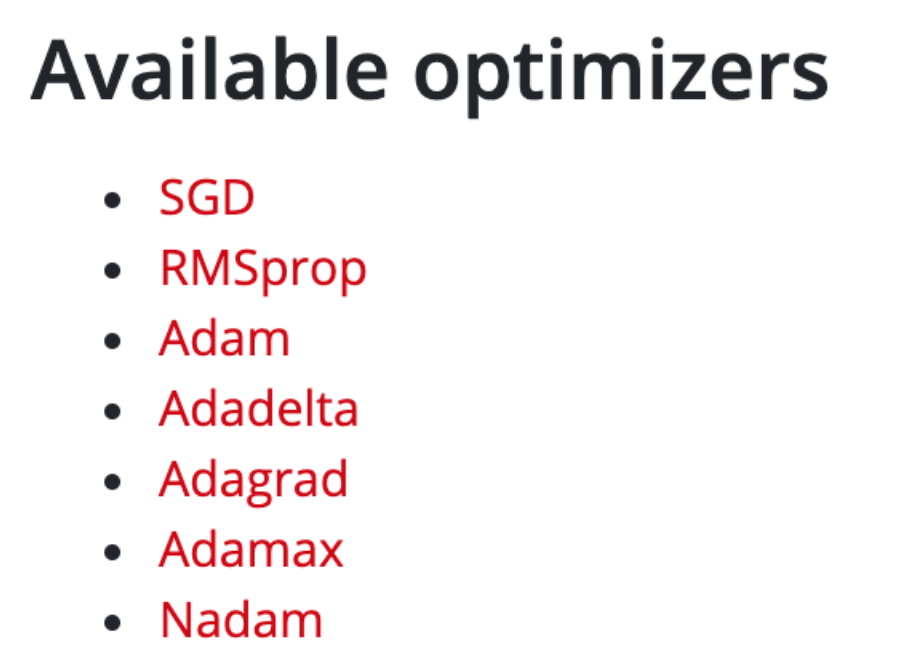

# Cargamos datos del libro 2

In [16]:
def cargar_datos():
    #Descargar datos
    (X_train, y_train), (X_test,y_test)=fashion_mnist.load_data()
    #le hacemos un reshape par tenerlo vectorizado (luego estandarizar)
    X_train=X_train.reshape((X_train.shape[0],28,28,1))#agregamos una dimensión
    X_test=X_test.reshape((X_test.shape[0],28,28,1))#agregamos una dimensión
    
    #One Hot Encoder
    y_train=tf.keras.utils.to_categorical(y_train)
    y_test=tf.keras.utils.to_categorical(y_test)
    
    return X_train, y_train, X_test, y_test
def escalar_imagen(train,test):
    #convertir a flotatntes y normalizar en el rango 0-1
    maximo=train.max()
    
    train_norm=train.astype("float32")/maximo
    test_norm=test.astype("float32")/maximo
    
    #regrese las imágenes normalizadas
    
    return train_norm, test_norm
def define_model():
    #El método que vamos a ver a continuacón define la Red en Keras Anidando
    #Capas
    Xin=Input(shape=(28,28,1))
    #lo pasamos a una dimensión, cada imagen la pasamon a un flatten
    #El flatten va a convertir una imagen de 28x28(matriz) a 784x1(fila)

    X=Flatten()(Xin)
    X=Dense(350,activation="relu")(X) #Anidamos (X), agregando info
    X=Dense(100,activation="relu")(X)
    X=Dense(10,activation="softmax")(X)
    model=Model(inputs=Xin,outputs=X)

    #opt=SGD(learning_rate=.01)
    model.compile(optimizer=opt,
                 loss="categorical_crossentropy",
                 metrics=["accuracy"])
    return model
#definir una validación cruzada en keras
def evaluar_modelo(dataX,dataY,n_folds=2):
    #Generamos 2 listas para el error y el accuracy
    scores,histories=list(),list()
    #Se generan los índices de la validación cruzada
    kfold=KFold(n_folds,shuffle=True,random_state=1)
    #para cada fold (le dicen qué índice del train y del test hay que tomar)
    for train_ix, test_ix in kfold.split(dataX):
        #Definimos el modelo
        model=define_model()

        #Seleccionamos las filas para entrenar y testear
        trainX,trainY,testX,testY=dataX[train_ix],dataY[train_ix],dataX[test_ix],dataY[test_ix]
        
        #fit al modelo, le pasamos entrenamiento y validación (verbose=0 no imprime nada)
        
        #aquí nos da la información de los epochs
        history=model.fit(trainX,trainY,epochs=5,validation_data=(testX,testY),verbose=0)
        
        #evaluamos el último epochs
        _, acc = model.evaluate(testX,testY,verbose=0)
        
        print(">%.3f"%(acc*100.0))
        scores.append(acc)
        histories.append(history)
    return scores,histories
def graficar_resumen(histories):
    for i in range(len(histories)):
        plt.subplot(211)
        plt.title("Classification Accuracy")
        plt.plot(histories[i].history["accuracy"],color="blue",label="train")
        plt.plot(histories[i].history["val_accuracy"],color="orange",label="test")
        plt.show()
        #plt.legend()     


In [17]:
def correr_todo():
    #cargar_datos
    trainX, trainY, testX, testY=cargar_datos()
    #escalamos
    trainX,testX=escalar_imagen(trainX,testX)
    #definimos el modelo
    modelo=define_model()
    #evaluamos el modelo
    scores,histories=evaluar_modelo(trainX,trainY)
    #graficar por epoch
    graficar_resumen(histories)

# Librerías del Libro 2


In [18]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
from numpy.random import seed, choice
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold,cross_val_score


# 1. SGD Plain Vanilla

>82.367
>84.797


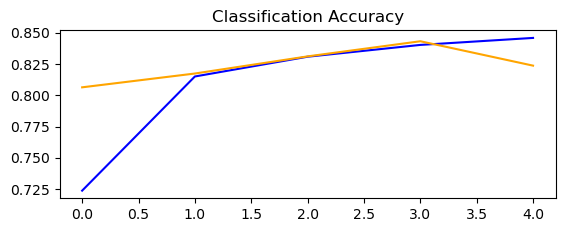

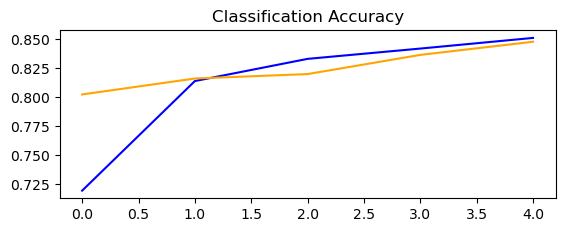

In [19]:
from tensorflow.keras.optimizers import SGD
opt=SGD(learning_rate=.01)
correr_todo()

# 2. Momentum


>83.427
>84.890


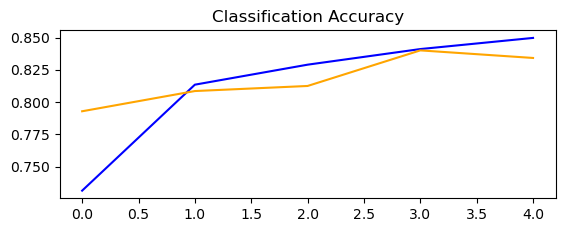

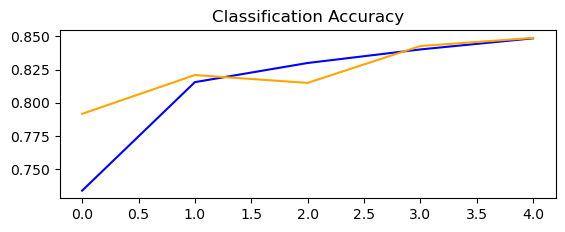

In [20]:
from tensorflow.keras.optimizers import SGD
opt=SGD(learning_rate=.01,momentum=0.9)
correr_todo()

# 3. Nesterov



>84.283
>83.217


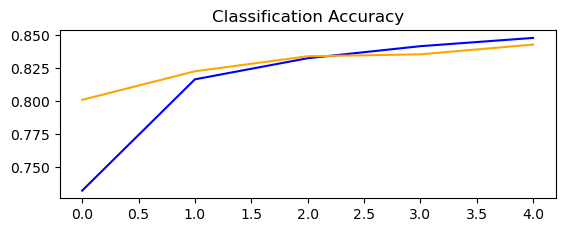

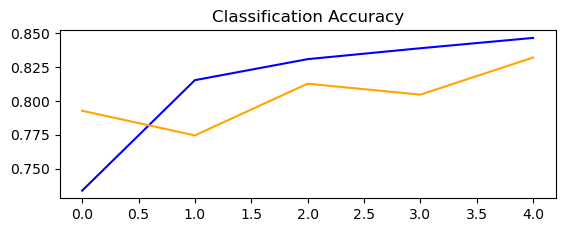

In [21]:
from tensorflow.keras.optimizers import SGD
opt=SGD(learning_rate=.01,momentum=0.9,nesterov=True)
correr_todo()

# 4. Adagrad


>84.477
>83.213


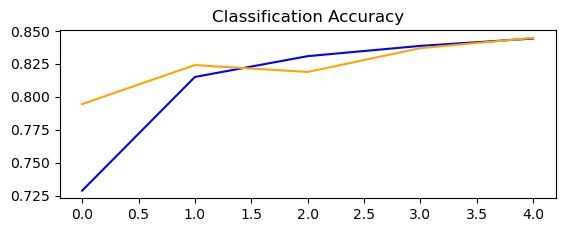

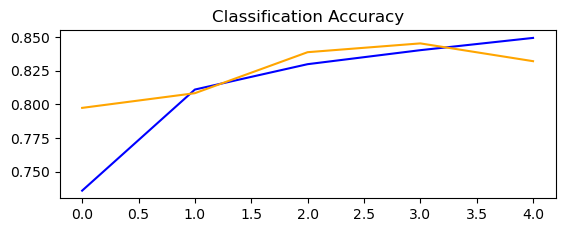

In [22]:
from tensorflow.keras.optimizers import Adagrad
opt=Adagrad(learning_rate=.01)
correr_todo()

# 5. RMSprop

>83.257
>84.887


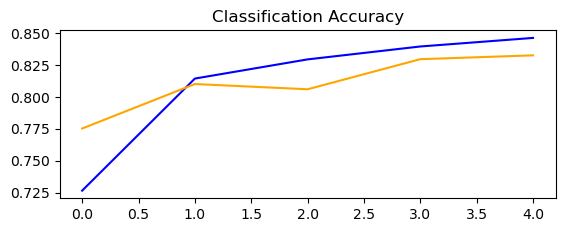

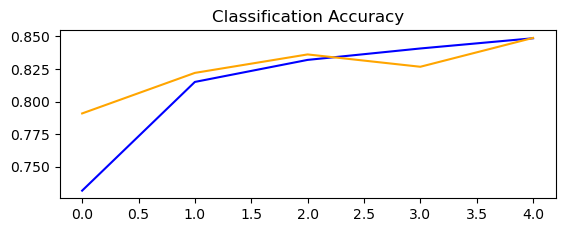

In [23]:
from tensorflow.keras.optimizers import RMSprop
opt=RMSprop(learning_rate=.01)
correr_todo()

# 6 Adadelta

>83.957
>84.163


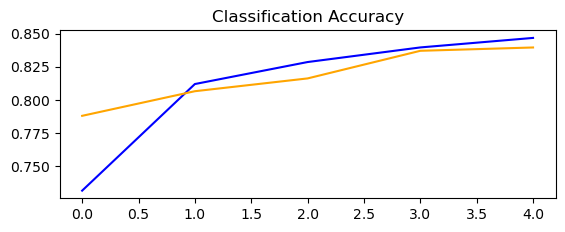

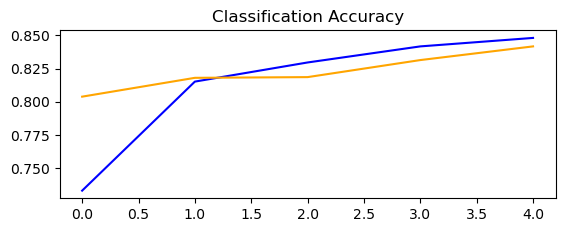

In [24]:
from tensorflow.keras.optimizers import Adadelta
opt=Adadelta(learning_rate=.01)
correr_todo()

# 7. Adam

>84.893
>84.487


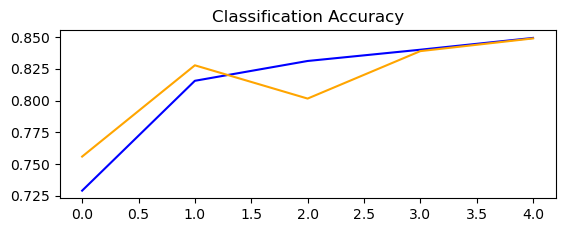

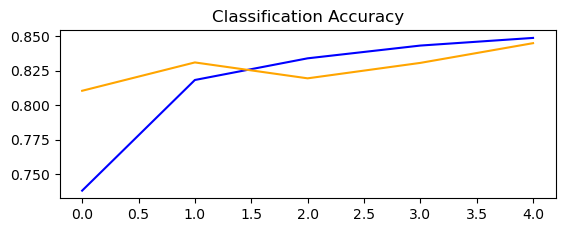

In [25]:
from tensorflow.keras.optimizers import Adam
opt=Adam(learning_rate=.01)
correr_todo()

# 8 AdaMax

>83.613
>85.167


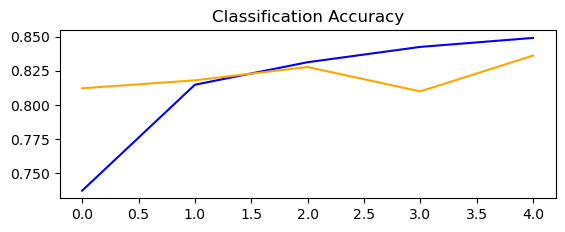

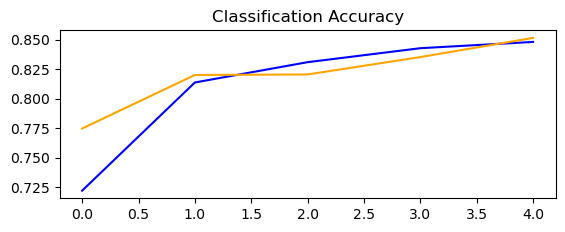

In [27]:
from tensorflow.keras.optimizers import Adamax
opt=Adamax(learning_rate=.01)
correr_todo()

# 9 Nadam

>85.240
>84.100


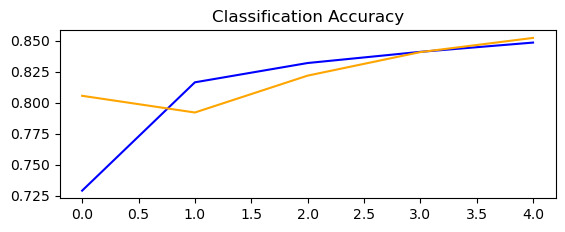

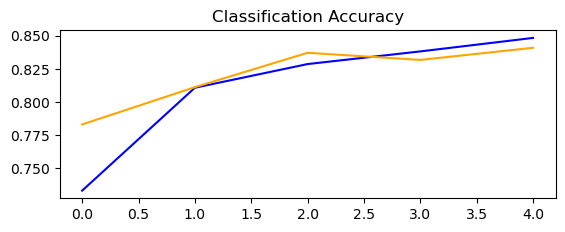

In [28]:
from tensorflow.keras.optimizers import Nadam
opt=Nadam(learning_rate=.01)
correr_todo()

# 10 AMS Grad

>84.760
>85.270


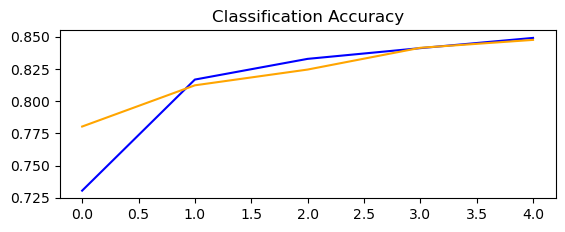

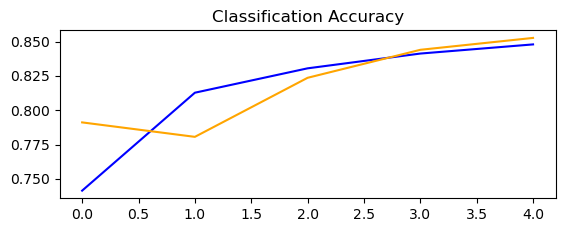

In [29]:
from tensorflow.keras.optimizers import Adam
opt=Adam(learning_rate=.01,amsgrad=True)
correr_todo()

# Tarea 4
Investigar los únicos cinco optimizadares que no vimos en clase: 
https://keras.io/api/optimizers/ftrl/

https://keras.io/api/optimizers/adafactor/

https://keras.io/api/optimizers/lion/

https://keras.io/api/optimizers/adamw/

https://keras.io/api/optimizers/loss_scale_optimizer/


1. Explicar con sus palabras a grandes que rasgos qué hace.(2-3 líneas si quieren) 

2. Replicar el ejercicio anterior
n_epochs=8
n_folds=3
De los resultados de los 10 métodos + (5 tarea) de arriba en nuestra base de Fashion, ¿cuáles fueron los mejores y peores? y ¿por qué creen que haya pasado eso?
n_epochs=8
n_folds=3
¿En donde parece que hay evidencia de sobre ajuste en las Curvas de Aprendizaje?